# Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [7]:
df = pd.read_csv("RF-HR-Employee-Attrition.csv")

print(df.shape)

df.head(5)

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Step 3: Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Step 4: Check Target Variable Distribusion

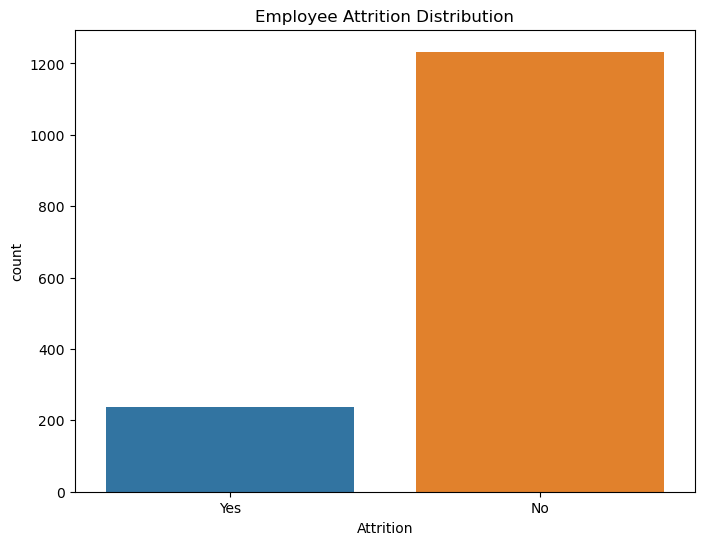

In [12]:
plt.figure(figsize = (8,6))

sns.countplot(x = "Attrition", data = df)

plt.title("Employee Attrition Distribution")

plt.show()

# Step 5: Remove Constant Columns

In [14]:
constant_columns = [
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df.drop(
    constant_columns,
    axis = 1, 
    inplace = True
)

print(df.shape)

(1470, 32)


# Step 6: Check Missing Values

In [15]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

# Step 7: Encode Categorical Columns

In [17]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,7,1,...,3,4,1,6,3,3,2,2,2,2


# Step 8: Correlation Heatmap

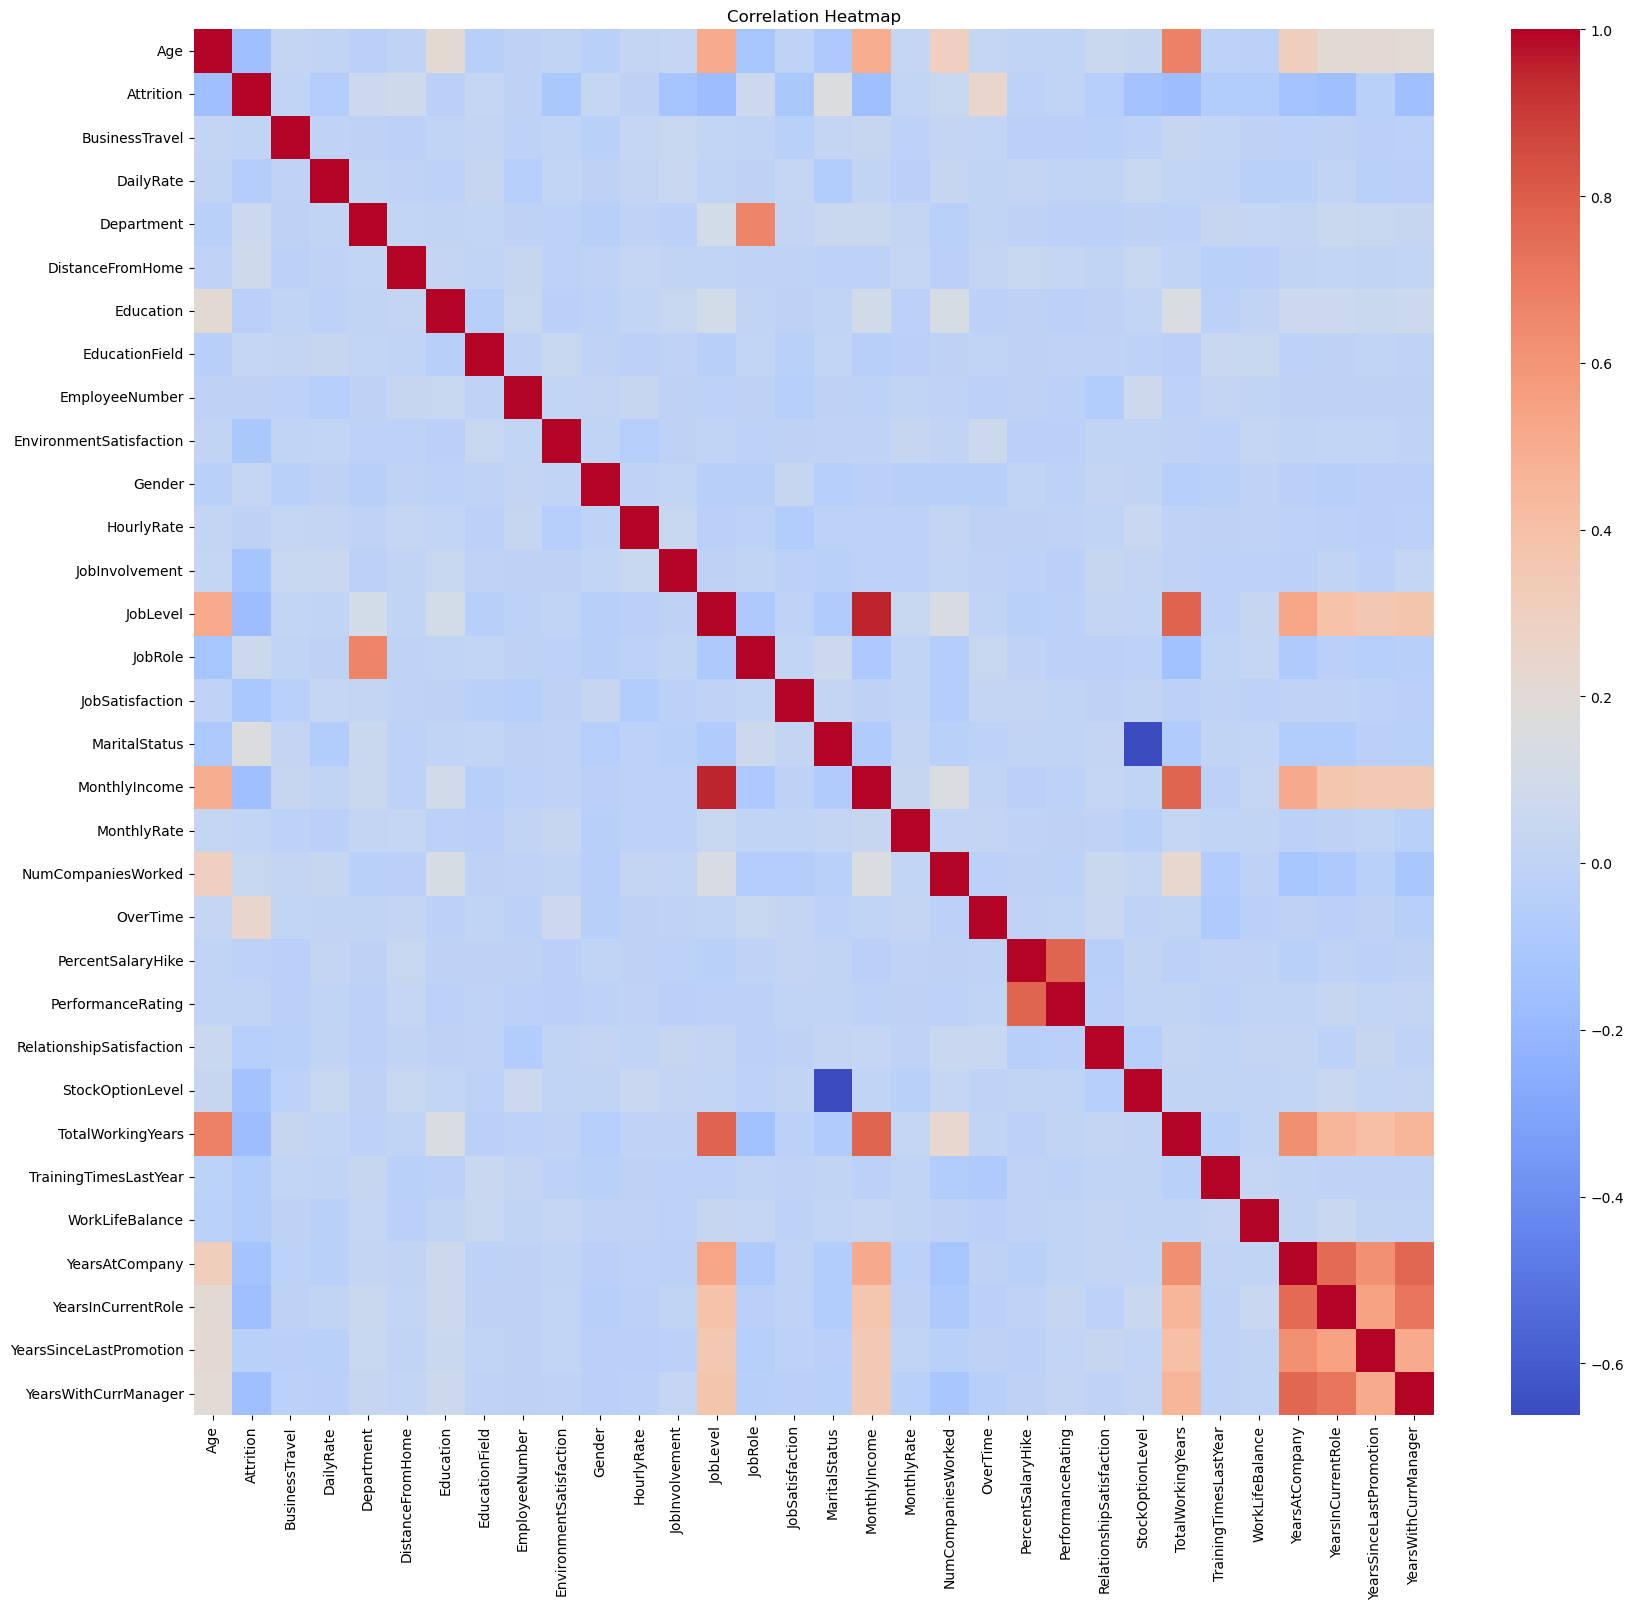

In [18]:
plt.figure(figsize= (20,18))

sns.heatmap(df.corr(),cmap = 'coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Step 9: Separate Features and Target

In [19]:
X = df.drop("Attrition", axis = 1)
y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 31)
(1470,)


# Step 10: Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test. shape)

Training Shape : (1176, 31)
Testing Shape : (294, 31)


# Step 11: Build Random Forest Model

In [22]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    random_state = 42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

# Step 12: Prediction

In [24]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


# Step 13: Accuracy Score

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print(
    "Accuracy :",
    round(accuracy*100,2),
    '%'
)

Accuracy : 83.33 %


# Step 14: Confusion Matrix

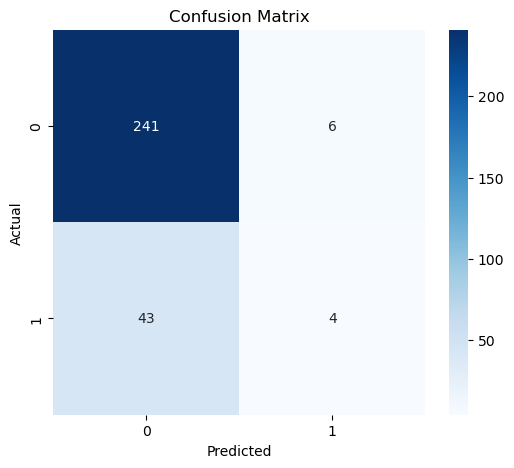

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 15: Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



# Step 16: Feature Importance

In [30]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : importance
})        

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

feature_importance.head(15)

,Feature,Importance
16,MonthlyIncome,0.078840
0,Age,0.066463
24,TotalWorkingYears,0.064904
2,DailyRate,0.052104
7,EmployeeNumber,0.046652
4,DistanceFromHome,0.046213
19,OverTime,0.044142
10,HourlyRate,0.044042
17,MonthlyRate,0.043110
27,YearsAtCompany,0.042212


# Step 17: Feature Importance Graph

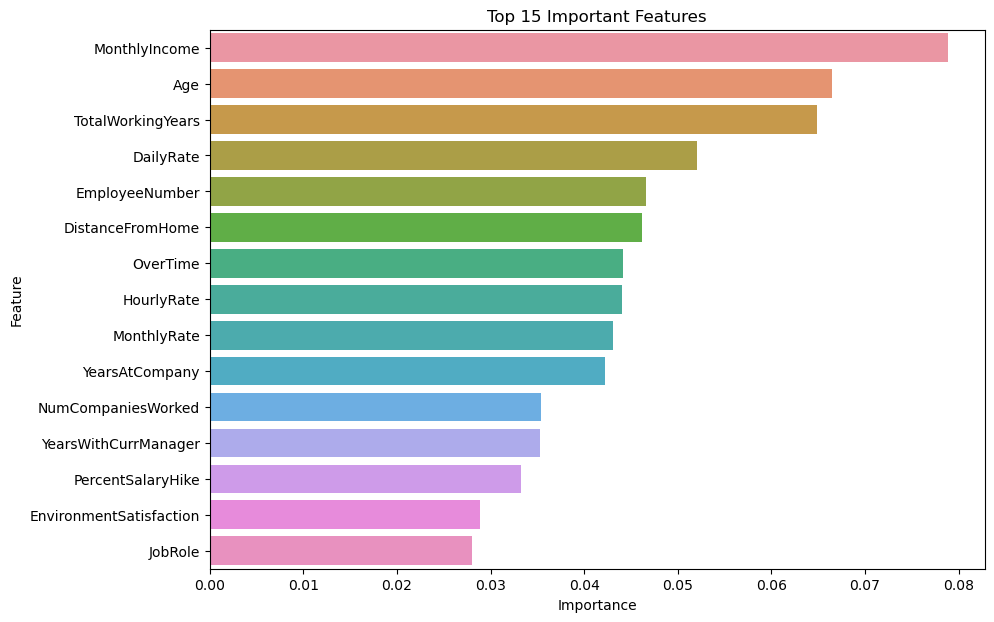

In [31]:
top_features = feature_importance.head(15)

plt.figure(figsize = (10,7))

sns.barplot(x = 'Importance', y = 'Feature', data = top_features)

plt.title("Top 15 Important Features")

plt.show()

# Step 18: ROC Curve

In [34]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC Score :", round(auc,4))

AUC Score : 0.804


# Step 19: ROC Curve Graph

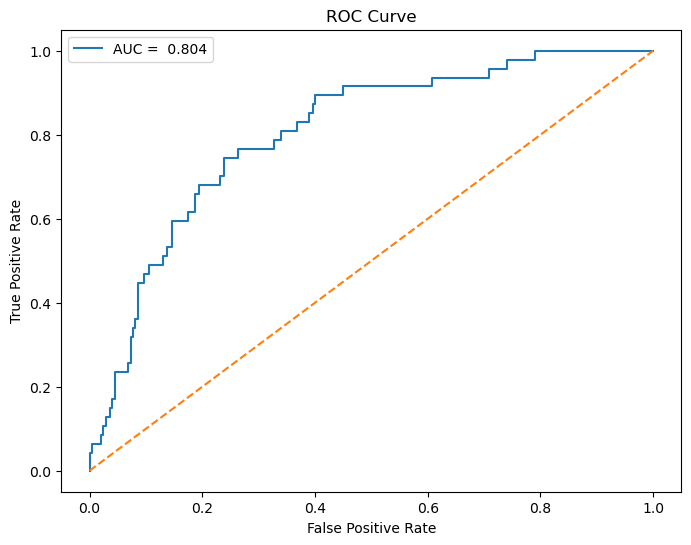

In [36]:
plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc : .3f}")
         
plt.plot([0,1], [0,1], linestyle = '--')

         
plt.title("ROC Curve")
         
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
         
plt.legend()
         
plt.show()

# Step 20: Actual vs Predicted

In [39]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted' : y_pred
})

comparison.head(20)

,Actual,Predicted
1061,0,0
891,0,0
456,0,0
922,0,0
69,1,0
1164,0,0
406,0,0
1330,0,0
1232,0,0
1311,0,1


# Step 21: Random Forest Tree Visualization

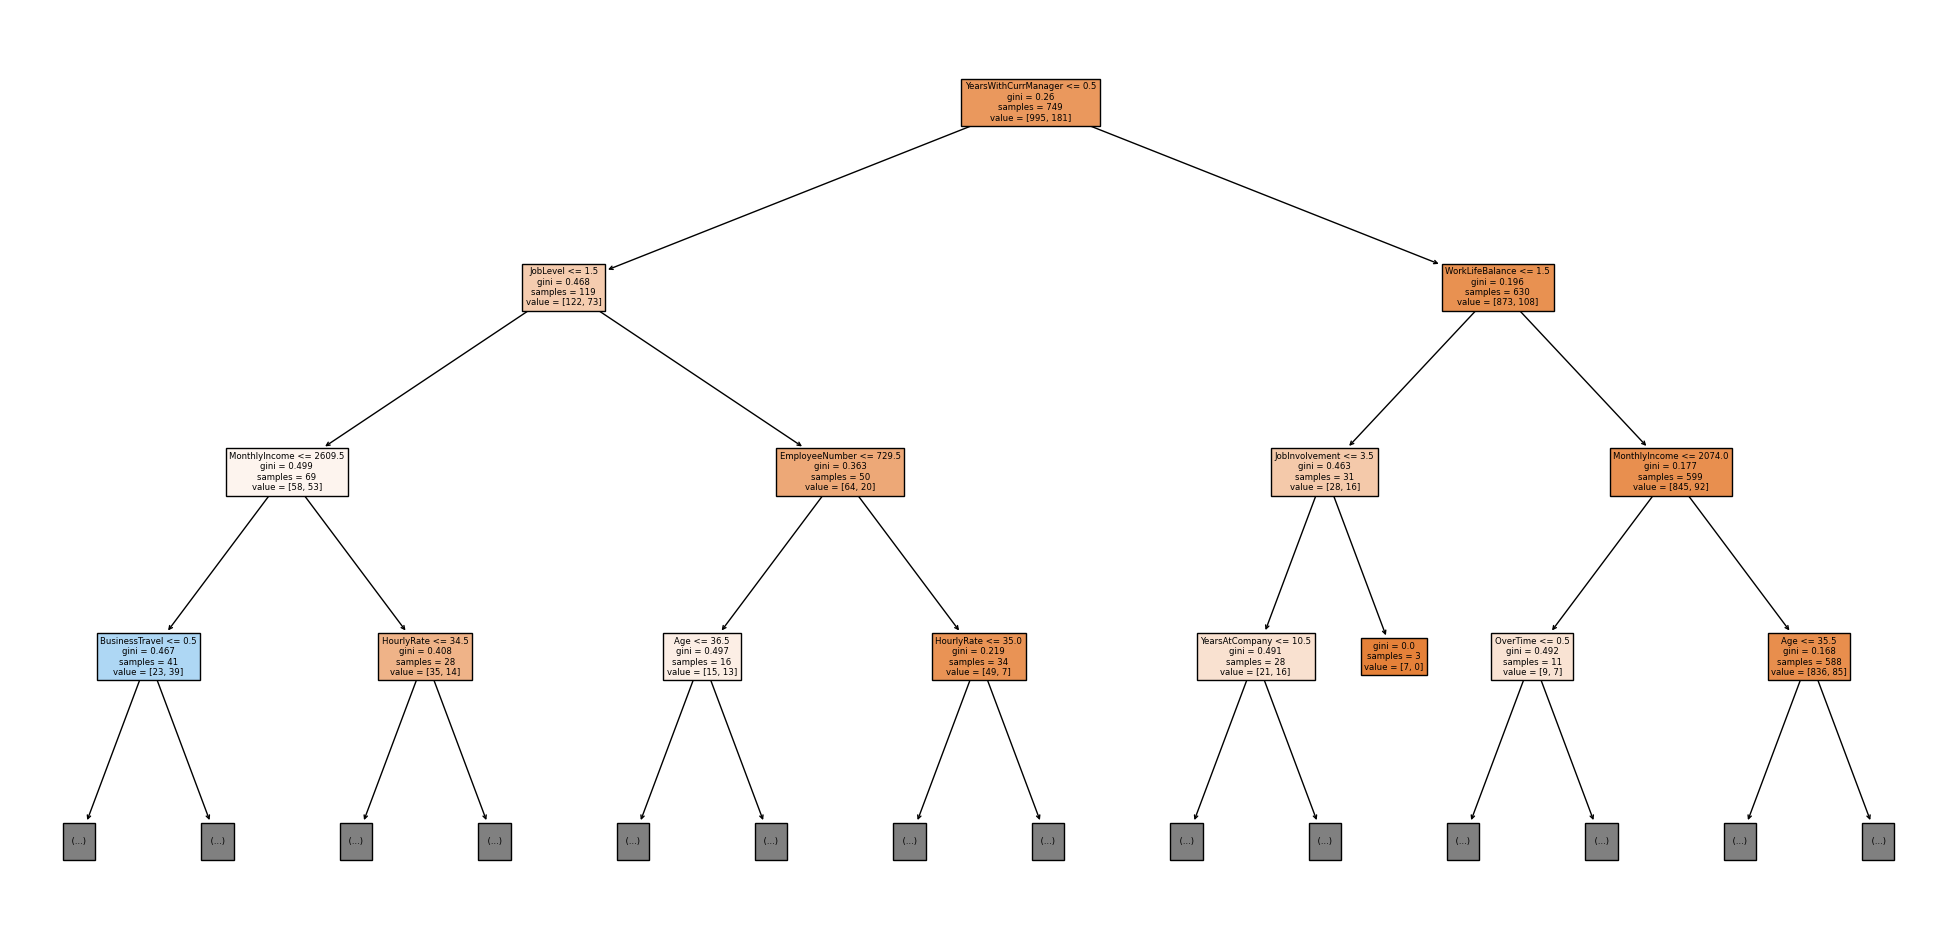

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize = (25,12))

plot_tree(
    rf_model.estimators_[0],
    feature_names = X.columns,
    filled = True,
    max_depth = 3
)

plt.show()

# Step 22: Training vs Testing Accuracy

In [41]:
train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_acc)

print("Testing Accuracy :", test_acc)

Training Accuracy : 0.9778911564625851
Testing Accuracy : 0.8333333333333334


# Step 23: Hyperparameter Tuned Random Forest

In [43]:
rf_tuned = RandomForestClassifier(
    n_estimators = 500,
    max_depth = 15,
    min_samples_split = 5,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    bootstrap = True,
    random_state = 42
)

rf_tuned.fit(X_train, y_train)

tuned_pred = rf_tuned.predict(X_test)

print("Tuned Accuracy :", accuracy_score(y_test, tuned_pred))

Tuned Accuracy : 0.8333333333333334


# Step 24: Top Attrition Drivers Visualization

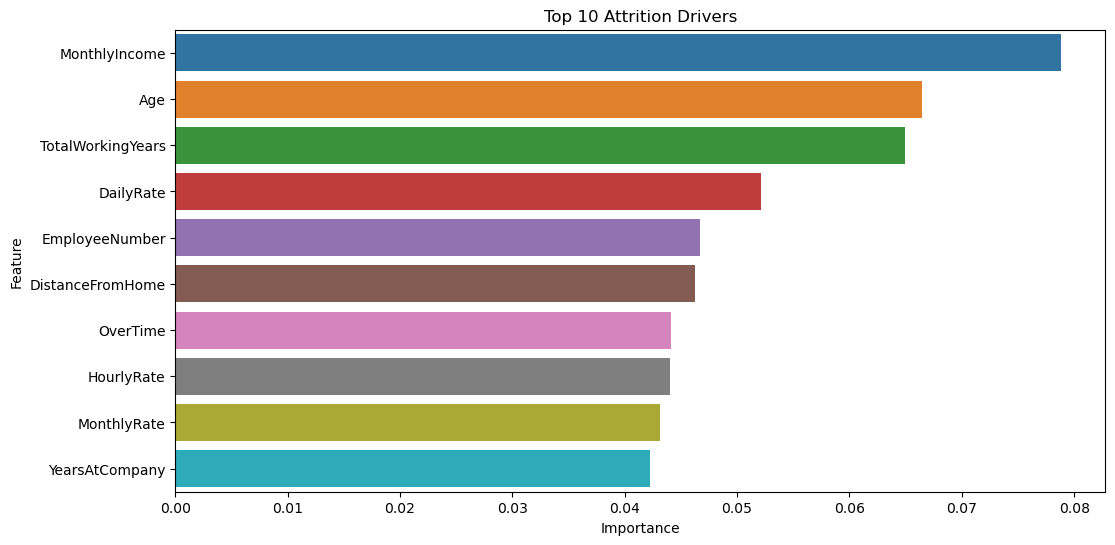

In [44]:
top10 = feature_importance.head(10)

plt.figure(figsize = (12,6))

sns.barplot(x = 'Importance', y = 'Feature', data = top10)

plt.title("Top 10 Attrition Drivers")

plt.show()